In [1]:
import torch

In [2]:
t_c = [0.5,  14.0, 15.0, 28.0, 11.0,  8.0,  3.0, -4.0,  6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]

t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

In [3]:
t_c.shape

torch.Size([11])

In [4]:
t_u.shape

torch.Size([11])

In [7]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


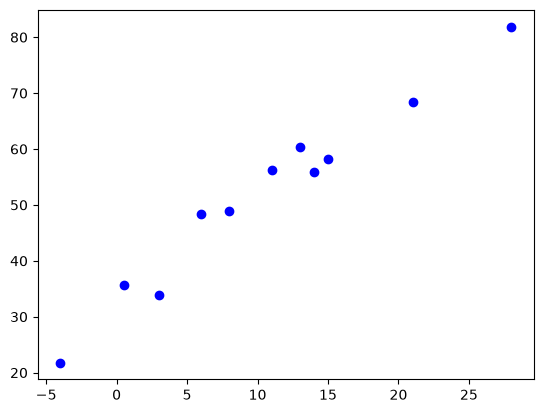

In [14]:
plt.plot(t_c, t_u, 'bo')
plt.show()

In [15]:
def model(t_u, w, b):
    return w * t_u + b

In [36]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)** 2
    return squared_diffs.mean()

In [31]:
w = torch.ones(())
b = torch.zeros(())

In [32]:
t_p = model(t_u, w, b)

In [33]:
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [37]:
loss = loss_fn(t_p, t_c)

In [38]:
loss

tensor(1763.8846)

In [56]:
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c) / t_p.size(0)
    return dsq_diffs

In [50]:
def dmodel_dw(t_u, w, b):
    return t_u

def dmodel_db(t_u, w, b):
    return 1

In [47]:
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp* dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])


In [61]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        w, b = params
        t_p = model(t_u, w, b)
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b)

        params = params - learning_rate * grad
        print(f'Epoch {epoch}, Loss {float(loss)}')
        print(f'Params: {params}')
        print(f'Grad: {grad}')

    return params

In [62]:
training_loop(
    n_epochs=100,
    learning_rate=1e-4,
    params = torch.tensor([1.0, 0.0]),
    t_u = t_u,
    t_c = t_c
)

Epoch 1, Loss 1763.8846435546875
Params: tensor([ 0.5483, -0.0083])
Grad: tensor([4517.2964,   82.6000])
Epoch 2, Loss 323.0905456542969
Params: tensor([ 0.3623, -0.0118])
Grad: tensor([1859.5492,   35.7843])
Epoch 3, Loss 78.92963409423828
Params: tensor([ 0.2858, -0.0135])
Grad: tensor([765.4666,  16.5122])
Epoch 4, Loss 37.5528450012207
Params: tensor([ 0.2543, -0.0143])
Grad: tensor([315.0790,   8.5787])
Epoch 5, Loss 30.540283203125
Params: tensor([ 0.2413, -0.0149])
Grad: tensor([129.6733,   5.3127])
Epoch 6, Loss 29.351158142089844
Params: tensor([ 0.2360, -0.0153])
Grad: tensor([53.3495,  3.9682])
Epoch 7, Loss 29.148881912231445
Params: tensor([ 0.2338, -0.0156])
Grad: tensor([21.9303,  3.4148])
Epoch 8, Loss 29.113847732543945
Params: tensor([ 0.2329, -0.0159])
Grad: tensor([8.9964, 3.1869])
Epoch 9, Loss 29.107145309448242
Params: tensor([ 0.2325, -0.0162])
Grad: tensor([3.6721, 3.0930])
Epoch 10, Loss 29.105247497558594
Params: tensor([ 0.2324, -0.0166])
Grad: tensor([1.480

tensor([ 0.2327, -0.0438])

# Autograd with pytorch

In [63]:
params = torch.tensor([1.0,0.0], requires_grad=True)

In [64]:
params.grad is None

True

In [66]:
loss = loss_fn(model(t_u, *params), t_c)

In [67]:
loss.backward()

In [68]:
params.grad

tensor([4517.2964,   82.6000])

In [70]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        if params.grad is not None:
            params.grad.zero_()
    
        w, b = params
        t_p = model(t_u, w, b)

        loss = loss_fn(t_p, t_c)
        loss.backward()

        with torch.no_grad():
            params -= learning_rate * params.grad

        if epoch % 500 == 0:
            print(f'Epoch: {epoch}, Loss: {float(loss)}')
        
    return params

In [72]:
t_un = 0.1 * t_u

In [73]:
training_loop(
    n_epochs=5000,
    learning_rate=1e-2,
    params = torch.tensor([1.0, 0.0], requires_grad=True),
    t_u = t_un,
    t_c = t_c
)

Epoch: 500, Loss: 7.860118389129639
Epoch: 1000, Loss: 3.828537702560425
Epoch: 1500, Loss: 3.092190742492676
Epoch: 2000, Loss: 2.9576973915100098
Epoch: 2500, Loss: 2.933133840560913
Epoch: 3000, Loss: 2.9286482334136963
Epoch: 3500, Loss: 2.927830696105957
Epoch: 4000, Loss: 2.9276795387268066
Epoch: 4500, Loss: 2.927651882171631
Epoch: 5000, Loss: 2.9276466369628906


tensor([  5.3671, -17.3012], requires_grad=True)

In [74]:
params=torch.tensor([1.0,0.0], requires_grad=True)
t_p = model(t_un, *params)


In [75]:
loss = loss_fn(t_p, t_c)

In [76]:
loss.backward()

In [79]:
import torch.optim as optim

In [80]:
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate)

In [81]:
optimizer.step()

In [82]:
params

tensor([1.0008e+00, 1.0640e-04], requires_grad=True)

In [85]:
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs+1):
        
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f'Epoch: {epoch}, Loss: {float(loss)}')

    return params
    

In [86]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-4
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    params=params,
    t_u=t_un,
    t_c=t_c
)

Epoch: 500, Loss: 29.505891799926758
Epoch: 1000, Loss: 28.943769454956055
Epoch: 1500, Loss: 28.505281448364258
Epoch: 2000, Loss: 28.074451446533203
Epoch: 2500, Loss: 27.65087890625
Epoch: 3000, Loss: 27.234447479248047
Epoch: 3500, Loss: 26.82501983642578
Epoch: 4000, Loss: 26.422496795654297
Epoch: 4500, Loss: 26.02674674987793
Epoch: 5000, Loss: 25.637670516967773


tensor([ 2.5233, -1.2029], requires_grad=True)

what optizer help is that we don't need to update the params manually and put inside torch.zero_grad(). And we don't need to manually check if params.grad is not None to zero grads. We easily achieve it with optimizer.zero_grad()